In [41]:
import pandas as pd
dataset=pd.read_csv('Breast_Cancer.csv').values
print(dataset.shape)
dataset

(4024, 16)


array([[68, 'White', 'Married', ..., 1, 60, 'Alive'],
       [50, 'White', 'Married', ..., 5, 62, 'Alive'],
       [58, 'White', 'Divorced', ..., 7, 75, 'Alive'],
       ...,
       [68, 'White', 'Married', ..., 3, 69, 'Alive'],
       [58, 'Black', 'Divorced', ..., 1, 72, 'Alive'],
       [46, 'White', 'Married', ..., 2, 100, 'Alive']], dtype=object)

In [42]:
data=dataset[:,0:14]
print(data)

[[68 'White' 'Married' ... 'Positive' 24 1]
 [50 'White' 'Married' ... 'Positive' 14 5]
 [58 'White' 'Divorced' ... 'Positive' 14 7]
 ...
 [68 'White' 'Married' ... 'Negative' 11 3]
 [58 'Black' 'Divorced' ... 'Positive' 11 1]
 [46 'White' 'Married' ... 'Positive' 7 2]]


In [43]:
target = dataset[:, 14:16]  # selects columns 14 and 15
print(target)


[[60 'Alive']
 [62 'Alive']
 [75 'Alive']
 ...
 [69 'Alive']
 [72 'Alive']
 [100 'Alive']]


In [44]:
import pandas as pd

df = pd.read_csv('Breast_Cancer.csv')
print(df.columns.tolist())


['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [45]:
import pandas as pd

df = pd.read_csv('Breast_Cancer.csv')

# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Now you can access 'T Stage' safely
print(df.columns.tolist())


['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [46]:
categorical_cols = ["Race", "Marital Status", "T Stage ", "N Stage", "6th Stage",
                    "differentiate", "A Stage", "Estrogen Status", "Progesterone Status"]


In [47]:
df = pd.read_csv('Breast_Cancer.csv')
df.columns = df.columns.str.strip()


In [48]:
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from tensorflow.keras.utils import to_categorical

# # -----------------------------
# # 1. Load dataset
# # -----------------------------

# # Features and targets
# X = df.iloc[:, 0:14]          # columns 0–13 → features
# status_target = df['Status']   # Alive/Dead classification
# survival_target = df['Survival Months']  # Regression target

# # -----------------------------
# # 2. Encode categorical features
# # -----------------------------
# categorical_cols = ["Race", "Marital Status", "T Stage", "N Stage", "6th Stage",
#                     "differentiate", "A Stage", "Estrogen Status", "Progesterone Status"]

# le = LabelEncoder()
# for col in categorical_cols:
#     X[col] = le.fit_transform(X[col])

# # -----------------------------
# # 3. Scale numeric features
# # -----------------------------
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # -----------------------------
# # 4. Encode target (Status)
# # -----------------------------
# status_target = le.fit_transform(status_target)   # Alive/Dead → 0/1
# status_target = to_categorical(status_target)    # One-hot encoding

# # -----------------------------
# # 5. Split dataset
# # -----------------------------
# X_train, X_test, y_status_train, y_status_test, y_surv_train, y_surv_test = train_test_split(
#     X_scaled, status_target, survival_target, test_size=0.2, random_state=42
# )

# # -----------------------------
# # 6. Build multi-output neural network
# # -----------------------------
# inputs = Input(shape=(X_train.shape[1],))

# # Shared hidden layers
# x = Dense(64, activation='relu')(inputs)
# x = Dense(128, activation='relu')(x)
# x = Dense(128, activation='relu')(x)

# # Output 1: Status (classification)
# status_output = Dense(2, activation='softmax', name='status_output')(x)

# # Output 2: Survival Months (regression)
# surv_output = Dense(1, activation='linear', name='surv_output')(x)

# # Build model
# model = Model(inputs=inputs, outputs=[status_output, surv_output])

# # Compile model with separate losses
# model.compile(optimizer='adam',
#               loss={'status_output': 'categorical_crossentropy',
#                     'surv_output': 'mse'},
#               metrics={'status_output': 'accuracy',
#                        'surv_output': 'mae'})

# # -----------------------------
# # 7. Train model
# # -----------------------------
# model.fit(X_train, [y_status_train, y_surv_train],
#           validation_data=(X_test, [y_status_test, y_surv_test]),
#           epochs=100,
#           batch_size=16)

# # -----------------------------
# # 8. Model summary
# # -----------------------------
# model.summary()


In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv('Breast_Cancer.csv')

# Strip spaces from column names
df.columns = df.columns.str.strip()

# -----------------------------
# 2. Identify features and targets
# -----------------------------
X = df.iloc[:, 0:14]          # features: columns 0–13
status_target = df['Status']   # Alive/Dead
survival_target = df['Survival Months']  # Regression target

# -----------------------------
# 3. Encode categorical features (including messy ones)
# -----------------------------
categorical_cols = ["Race", "Marital Status", "T Stage", "N Stage", "6th Stage",
                    "differentiate", "A Stage", "Estrogen Status", "Progesterone Status", "Grade"]

le_dict = {}
for col in categorical_cols:
    X[col] = X[col].astype(str)             # ensure all values are string
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le                       # save LabelEncoder if needed later

# -----------------------------
# 4. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 5. Encode target (Status)
# -----------------------------
le_status = LabelEncoder()
status_target = le_status.fit_transform(status_target)  # Alive/Dead → 0/1
status_target = to_categorical(status_target)          # one-hot encoding

# -----------------------------
# 6. Split dataset
# -----------------------------
X_train, X_test, y_status_train, y_status_test, y_surv_train, y_surv_test = train_test_split(
    X_scaled, status_target, survival_target, test_size=0.2, random_state=42
)

# -----------------------------
# 7. Build multi-output neural network
# -----------------------------
inputs = Input(shape=(X_train.shape[1],))

# Shared hidden layers
x = Dense(64, activation='relu')(inputs)
x = Dense(128, activation='relu')(x)
x = Dense(128, activation='relu')(x)

# Output 1: Status (classification)
status_output = Dense(2, activation='softmax', name='status_output')(x)

# Output 2: Survival Months (regression)
surv_output = Dense(1, activation='linear', name='surv_output')(x)

# Build model
model = Model(inputs=inputs, outputs=[status_output, surv_output])

# Compile model with separate losses
model.compile(optimizer='adam',
              loss={'status_output': 'categorical_crossentropy',
                    'surv_output': 'mse'},
              metrics={'status_output': 'accuracy',
                       'surv_output': 'mae'})

# -----------------------------
# 8. Train the model
# -----------------------------
history = model.fit(X_train, [y_status_train, y_surv_train],
                    validation_data=(X_test, [y_status_test, y_surv_test]),
                    epochs=200,
                    batch_size=16)

# -----------------------------
# 9. Model summary
# -----------------------------
model.summary()

# -----------------------------
# 10. Example predictions
# -----------------------------
pred_status, pred_survival = model.predict(X_test)

# Convert predicted status from one-hot to label
pred_status_label = np.argmax(pred_status, axis=1)

print("Predicted Status (0=Dead,1=Alive):", pred_status_label[:10])
print("Predicted Survival Months:", pred_survival[:10].flatten())


Epoch 1/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2887.6472 - status_output_accuracy: 0.8150 - status_output_loss: 0.5308 - surv_output_loss: 2887.0903 - surv_output_mae: 44.8285 - val_loss: 602.2134 - val_status_output_accuracy: 0.8509 - val_status_output_loss: 0.4449 - val_surv_output_loss: 597.2319 - val_surv_output_mae: 19.9578
Epoch 2/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 583.9529 - status_output_accuracy: 0.8554 - status_output_loss: 0.4129 - surv_output_loss: 583.5192 - surv_output_mae: 19.5746 - val_loss: 564.1617 - val_status_output_accuracy: 0.8621 - val_status_output_loss: 0.4028 - val_surv_output_loss: 560.2585 - val_surv_output_mae: 19.1726
Epoch 3/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 552.4470 - status_output_accuracy: 0.8602 - status_output_loss: 0.3991 - surv_output_loss: 552.0405 - surv_output_mae: 19.1068 - val_loss: 564.5764 - val_status_output_accuracy: 0.8596 - val_status_output_loss: 0.3898 - val_surv_output_loss: 558.8259 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        960 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      8,320 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     16,512 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ status_output       │ (None, 2)         │        258 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surv_output (Dense) │ (None, 1)         │        129 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,539 (306.80 KB)

 Trainable params: 26,179 (102.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,360 (204.54 KB)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predicted Status (0=Dead,1=Alive): [0 0 0 0 0 0 0 0 1 0]
Predicted Survival Months: [89.054474 75.01607  90.6204   86.82253  72.34073  81.03775  76.58375
 60.97396  67.84186  56.38159 ]


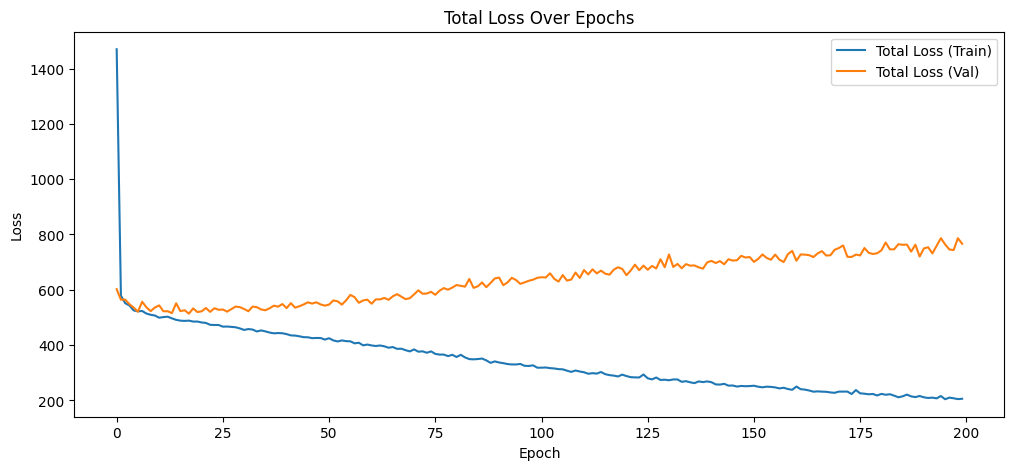

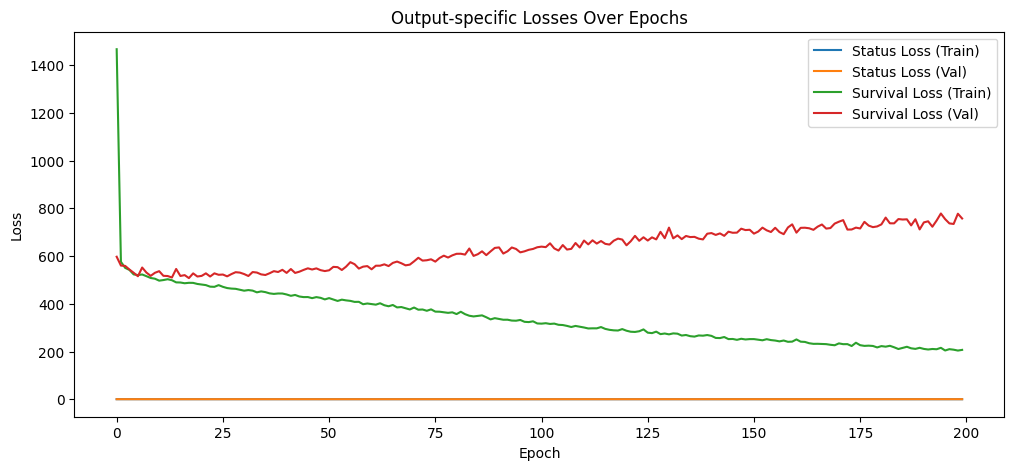

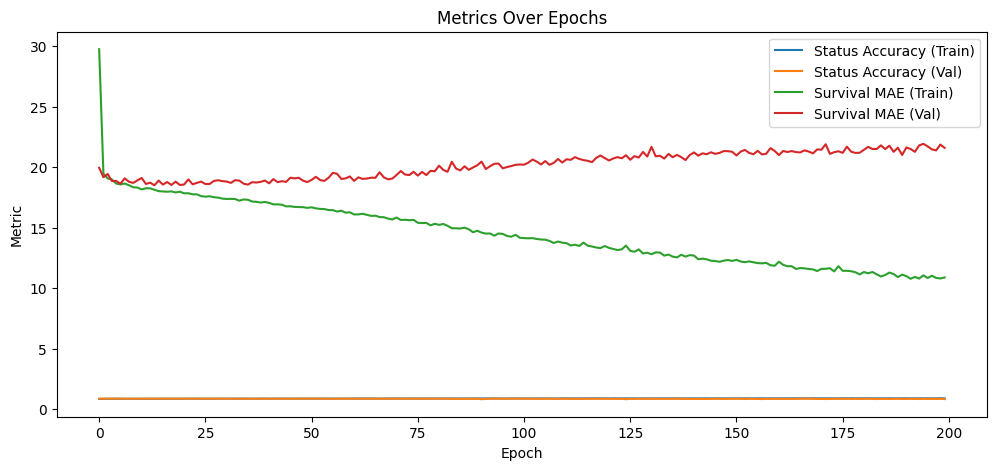

In [51]:
import matplotlib.pyplot as plt

# 'history' is returned by model.fit()
# history.history contains all losses and metrics

# -----------------------------
# Plot total loss
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Total Loss (Train)')
plt.plot(history.history['val_loss'], label='Total Loss (Val)')
plt.title('Total Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -----------------------------
# Plot output-specific losses
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(history.history['status_output_loss'], label='Status Loss (Train)')
plt.plot(history.history['val_status_output_loss'], label='Status Loss (Val)')
plt.plot(history.history['surv_output_loss'], label='Survival Loss (Train)')
plt.plot(history.history['val_surv_output_loss'], label='Survival Loss (Val)')
plt.title('Output-specific Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -----------------------------
# Plot metrics
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(history.history['status_output_accuracy'], label='Status Accuracy (Train)')
plt.plot(history.history['val_status_output_accuracy'], label='Status Accuracy (Val)')
plt.plot(history.history['surv_output_mae'], label='Survival MAE (Train)')
plt.plot(history.history['val_surv_output_mae'], label='Survival MAE (Val)')
plt.title('Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.legend()
plt.show()


Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3212.9277 - status_output_accuracy: 0.5276 - status_output_loss: 1.3168 - surv_output_loss: 3211.5552 - surv_output_mae: 48.7920 - val_loss: 618.4074 - val_status_output_accuracy: 0.8509 - val_status_output_loss: 0.8468 - val_surv_output_loss: 611.1943 - val_surv_output_mae: 20.2710
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 732.9404 - status_output_accuracy: 0.7514 - status_output_loss: 1.2886 - surv_output_loss: 731.6469 - surv_output_mae: 21.8480 - val_loss: 580.4668 - val_status_output_accuracy: 0.8509 - val_status_output_loss: 0.5303 - val_surv_output_loss: 573.9305 - val_surv_output_mae: 19.6278
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 733.0186 - status_output_accuracy: 0.7334 - status_output_loss: 0.9936 - surv_output_loss: 732.0167 - surv_output_mae: 21.9637 - val_loss: 599.3651 - val_status_output_accuracy: 0.8509 - val_status_output_loss: 0.5508 - val_surv_output_loss: 591.9048

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │      8,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ status_output       │ (None, 2)         │        130 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surv_output (Dense) │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,195 (207.80 KB)

 Trainable params: 17,731 (69.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,464 (138.54 KB)

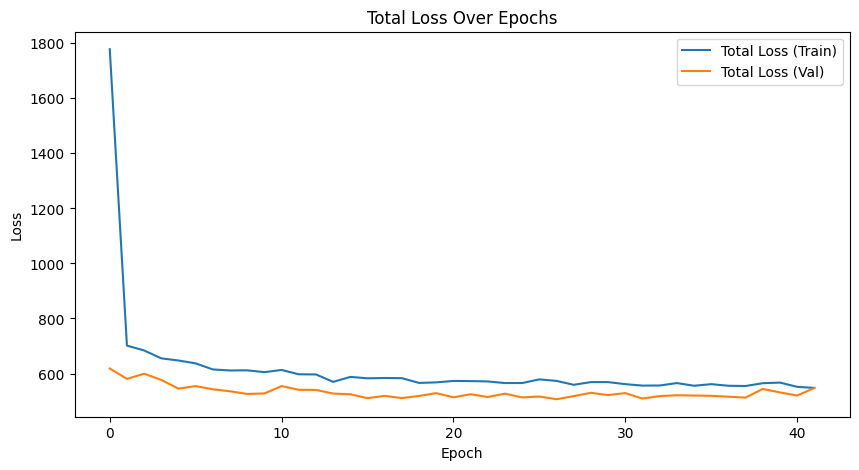

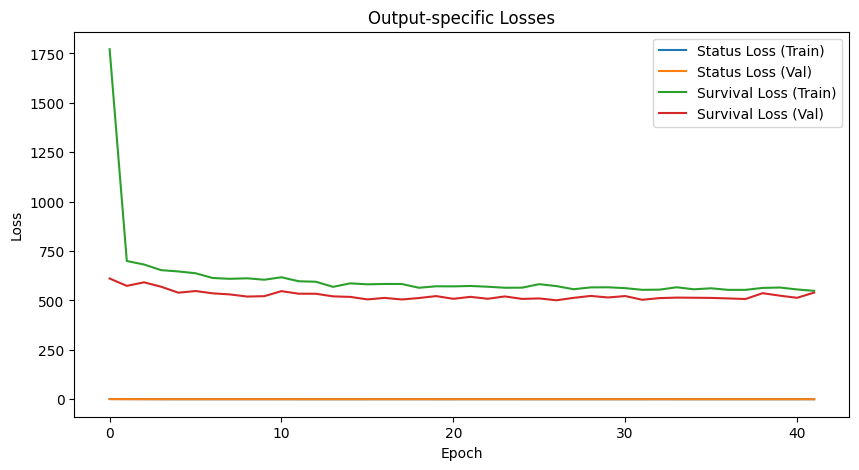

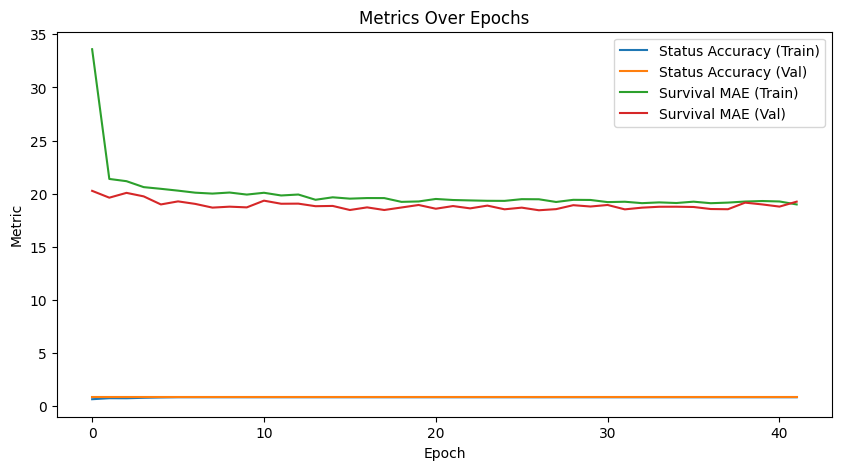

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted Status (0=Dead,1=Alive): [0 0 0 0 0 0 0 0 0 0]
Predicted Survival Months: [78.26303  72.41544  68.427925 73.21354  73.583984 73.27101  71.718414
 73.09947  67.930214 68.311485]


In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv('Breast_Cancer.csv')

# Strip spaces from column names
df.columns = df.columns.str.strip()

# -----------------------------
# 2. Identify features and targets
# -----------------------------
X = df.iloc[:, 0:14]          # features: columns 0–13
status_target = df['Status']   # Alive/Dead
survival_target = df['Survival Months']  # Regression target

# -----------------------------
# 3. Encode categorical features
# -----------------------------
categorical_cols = ["Race", "Marital Status", "T Stage", "N Stage", "6th Stage",
                    "differentiate", "A Stage", "Estrogen Status", "Progesterone Status", "Grade"]

le_dict = {}
for col in categorical_cols:
    X[col] = X[col].astype(str)             # ensure all values are strings
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le                       # save LabelEncoder if needed

# -----------------------------
# 4. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 5. Encode target (Status)
# -----------------------------
le_status = LabelEncoder()
status_target = le_status.fit_transform(status_target)  # Alive/Dead → 0/1
status_target = to_categorical(status_target)          # one-hot encoding

# -----------------------------
# 6. Split dataset
# -----------------------------
X_train, X_test, y_status_train, y_status_test, y_surv_train, y_surv_test = train_test_split(
    X_scaled, status_target, survival_target, test_size=0.2, random_state=42
)

# -----------------------------
# 7. Build multi-output neural network with dropout
# -----------------------------
inputs = Input(shape=(X_train.shape[1],))
x = Dense(64, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

# Output 1: Status (classification)
status_output = Dense(2, activation='softmax', name='status_output')(x)

# Output 2: Survival Months (regression)
surv_output = Dense(1, activation='linear', name='surv_output')(x)

# Build model
model = Model(inputs=inputs, outputs=[status_output, surv_output])

# Compile model with separate losses
model.compile(optimizer='adam',
              loss={'status_output': 'categorical_crossentropy',
                    'surv_output': 'mse'},
              metrics={'status_output': 'accuracy',
                       'surv_output': 'mae'})

# -----------------------------
# 8. EarlyStopping to prevent overfitting
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# -----------------------------
# 9. Train the model
# -----------------------------
history = model.fit(X_train, [y_status_train, y_surv_train],
                    validation_data=(X_test, [y_status_test, y_surv_test]),
                    epochs=100,          # reduced epochs
                    batch_size=16,
                    callbacks=[early_stop])

# -----------------------------
# 10. Model summary
# -----------------------------
model.summary()

# -----------------------------
# 11. Plot training history
# -----------------------------
import matplotlib.pyplot as plt

# Total loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Total Loss (Train)')
plt.plot(history.history['val_loss'], label='Total Loss (Val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss Over Epochs')
plt.legend()
plt.show()

# Output-specific losses
plt.figure(figsize=(10,5))
plt.plot(history.history['status_output_loss'], label='Status Loss (Train)')
plt.plot(history.history['val_status_output_loss'], label='Status Loss (Val)')
plt.plot(history.history['surv_output_loss'], label='Survival Loss (Train)')
plt.plot(history.history['val_surv_output_loss'], label='Survival Loss (Val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Output-specific Losses')
plt.legend()
plt.show()

# Metrics
plt.figure(figsize=(10,5))
plt.plot(history.history['status_output_accuracy'], label='Status Accuracy (Train)')
plt.plot(history.history['val_status_output_accuracy'], label='Status Accuracy (Val)')
plt.plot(history.history['surv_output_mae'], label='Survival MAE (Train)')
plt.plot(history.history['val_surv_output_mae'], label='Survival MAE (Val)')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Metrics Over Epochs')
plt.legend()
plt.show()

# -----------------------------
# 12. Example predictions
# -----------------------------
pred_status, pred_survival = model.predict(X_test)

# Convert predicted status from one-hot to label
pred_status_label = np.argmax(pred_status, axis=1)

print("Predicted Status (0=Dead,1=Alive):", pred_status_label[:10])
print("Predicted Survival Months:", pred_survival[:10].flatten())


In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Make predictions on the test set
# -----------------------------
pred_status, pred_survival = model.predict(X_test)

# -----------------------------
# 2. Convert predicted status from one-hot to labels
# -----------------------------
pred_status_label = np.argmax(pred_status, axis=1)
true_status_label = np.argmax(y_status_test, axis=1)

# -----------------------------
# 3. Classification evaluation (Status)
# -----------------------------
accuracy = accuracy_score(true_status_label, pred_status_label)
print("Classification Accuracy (Status):", accuracy)

print("\nClassification Report:\n", classification_report(true_status_label, pred_status_label))
print("\nConfusion Matrix:\n", confusion_matrix(true_status_label, pred_status_label))

# -----------------------------
# 4. Regression evaluation (Survival Months)
# -----------------------------
# Flatten arrays if needed
y_surv_true = y_surv_test.values if hasattr(y_surv_test, 'values') else y_surv_test
y_surv_pred = pred_survival.flatten()

mae = mean_absolute_error(y_surv_true, y_surv_pred)
mse = mean_squared_error(y_surv_true, y_surv_pred)
r2 = r2_score(y_surv_true, y_surv_pred)

print("\nRegression Evaluation (Survival Months):")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R² Score): {r2:.2f}")

# -----------------------------
# 5. Compare predictions vs true values
# -----------------------------
comparison = pd.DataFrame({
    'True_Status': true_status_label,
    'Pred_Status': pred_status_label,
    'True_Survival': y_surv_true,
    'Pred_Survival': y_surv_pred
})

print("\nComparison of first 10 test samples:")
print(comparison.head(10))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Accuracy (Status): 0.8509316770186336

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       685
           1       0.00      0.00      0.00       120

    accuracy                           0.85       805
   macro avg       0.43      0.50      0.46       805
weighted avg       0.72      0.85      0.78       805


Confusion Matrix:
 [[685   0]
 [120   0]]

Regression Evaluation (Survival Months):
Mean Absolute Error (MAE): 18.44
Mean Squared Error (MSE): 506.22
R-squared (R² Score): 0.05

Comparison of first 10 test samples:
   True_Status  Pred_Status  True_Survival  Pred_Survival
0            0            0             80      78.263031
1            0            0             48      72.415443
2            0            0             61      68.427925
3            1            0             53      73.213539
4            0            0             94      7

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
